In [321]:
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from scipy.signal import lfilter, firwin, freqz, zpk2tf, tf2zpk
from IPython.display import Audio
rfft = np.fft.rfft

def filterresponse(b, a, sr=44100, freq_scale='log', phase_scale='log', axs=None, **kwargs):
    w, h = freqz(b,a)

    if axs is not None:
        ax1 = axs[0]
    else:
        ax1 = plt.subplot(2,1,1)
    ax1.plot(w/max(w)*sr/2, 20 * np.log10(abs(h)+1e-5), **kwargs)
    ax1.set_xscale(freq_scale)
    ax1.set_ylabel('Ganancia (dB)')
    ax1.set_xlabel('Frecuencia (Hz)')
    ax1.set_title('Respuesta en frecuencia de la Amplitud')
    ax1.grid()    

    if axs is not None:
        ax2 = axs[1]
    else:
        ax2 = plt.subplot(2,1,2)
    angles = np.unwrap(np.angle(h))
    ax2.plot(w/max(w)*sr/2, angles, **kwargs)
    ax2.set_xscale(phase_scale)
    ax2.set_ylabel('Ángulo (radianes)')
    ax2.set_xlabel('Frecuencia (Hz)')
    ax2.set_title('Respuesta en frecuencia de la Fase')
    ax2.grid()
    plt.tight_layout()
    return ax1, ax2

def plotspectrum(x, sr=44100.0, xscale='linear', units='db', fmt = '-'):
    N = len(x)
    F = 2*(np.abs(rfft(x))/N)**2
    if units=='db':
        F = 10*np.log10(F)
        ylabel = 'Potencia dB'
    else:
        ylabel = 'Potencia'
    df = sr/N
    f = np.arange(F.size)*df
    plt.plot(f,F,fmt)
    plt.xscale(xscale)
    plt.xlabel('Frecuencia (hz)')
    plt.ylabel(ylabel)
    return F
    

# Codigo: Filtros

## Filtros FIR

Los filtros FIR (del ingles Finite Impulse Response) son filtros digitales en los cuales todos los coeficientes $a_n$ son cero salvo el $a_0$ ya que sino no habría salida. Es decir en los FIR son sólo se procesan los datos de la entrada $x_n$:

$$\displaystyle y_{n} = \sum_{k=0}^{N} b_{k} x_{n-k}$$

Esto equivale a la convolución de la entrada $x_n$ con los coeficientes $b_n$: $y_n = (x * b)_n$. Por lo que los coeficientes $b$ pueden identificarse como la respuesta impulso del filtro.

A continuación analizaremos algunos ejemplos de filtros FIR. El primero y más sencillo es hacer un promedio con $N$ valores de la entrada.

$$\displaystyle y_{n} = \frac{x_n + x_{n-1} + \cdots + x_{n-N-1 }}{N}$$

Esto indica que los coeficientes $b$ son todos iguales a $1/N$.


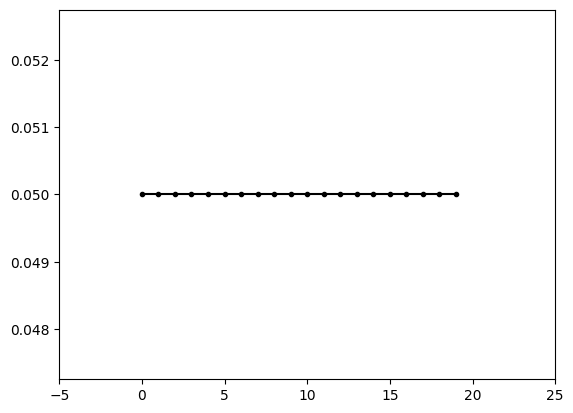

In [322]:
N = 20
b = [1/N]*N
a = [1]

plt.plot(b,'.k-')
plt.xlim(-5,25);

La forma de la respuesta impulso es constante.

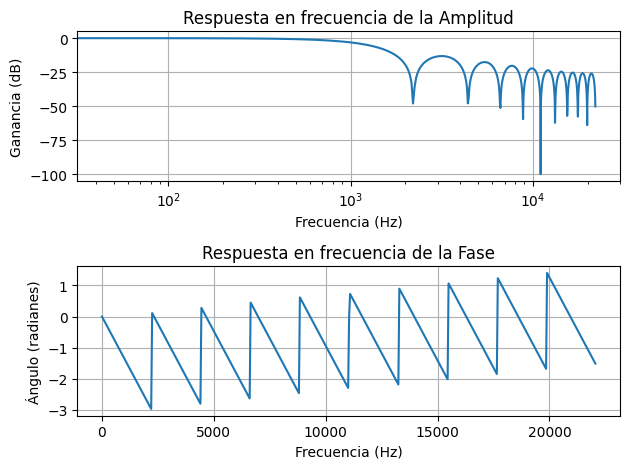

In [323]:
filterresponse(b,a, phase_scale='linear');

Podemos ver que el efecto de un filtro que promedia la entrada es de pasabajos. Es posible obtener filtros pasabajos con respuestas impulsos con forma de campana o tipo ventanas. La función _firwin_ de scipy permite crear filtros FIR con diferentes tipos de ventanas. Los parámetros de la función son:

```python
scipy.signal.firwin(numtaps, cutoff, window='hamming', pass_zero='lowpass')
```
Donde:
- **numtaps**: número de coeficientes del filtro.
- **cutoff**: frecuencia de corte del filtro.
- **window**: tipo de ventana a utilizar. Puede ser 'hamming', 'blackman', 'hanning', 'bartlett', 'kaiser' o 'boxcar'.
- **pass_zero**: tipo de filtro. Puede ser 'lowpass', 'highpass', 'bandpass' o 'bandstop'.

La función devuelve un array con los coeficientes del filtro.

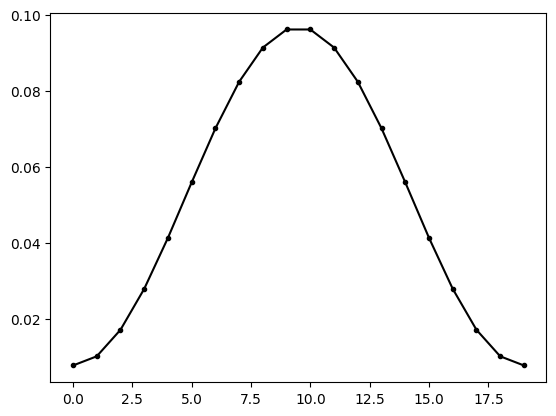

In [324]:
b = firwin(20, 0.001)
plt.plot(b,'.k-');

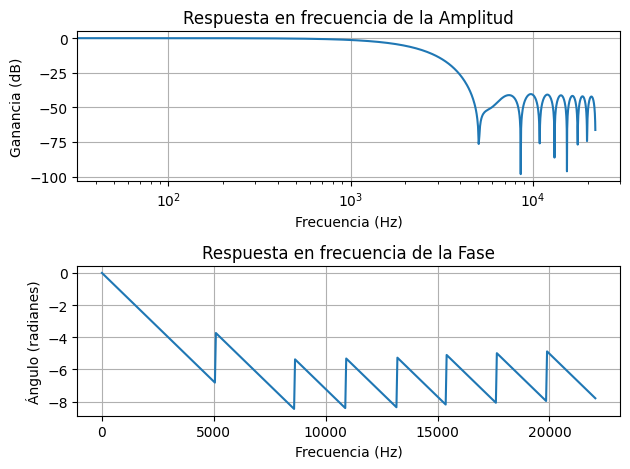

In [325]:
filterresponse(b,[1], phase_scale='linear');

## Filtros IIR

Los filtros IIR (del ingles Infinite Impulse Response) son filtros digitales en los cuales los coeficientes $a_n$ no son cero. Esto significa que la salida depende de la entrada y de la salida anterior. La ecuación general de un filtro IIR es:


$$\displaystyle y_{n} = \sum_{k=0}^{N} b_{k} x_{n-k} - \sum_{k=1}^{M} a_{k} y_{n-k}$$

### Filtros biquads:

Son filtros IIR de segundo orden. La ecuación general es:

$$
a_0 y_{n} = b_0 x_{n} + b_1 x_{n-1} + b_2 x_{n-2} - a_1 y_{n-1} - a_2 y_{n-2}
$$

La función de transferencia de un filtro biquad es:

$$
H(z) = \frac{b_0 + b_1 z^{-1} + b_2 z^{-2}}{a_0 + a_1 z^{-1} + a_2 z^{-2}}
$$

Seteando los coeficientes se pueden obtener filtros pasa bajos, pasa altos, pasa banda y rechaza banda, shelving y peaking.

https://webaudio.github.io/Audio-EQ-Cookbook/audio-eq-cookbook.html

Para un filtro pasa bajos de segundo orden se puede usar la siguiente configuración en función de la frecuencia de corte $f_c$, la frecuencia de muestreo $f_s$ y el factor de calidad $Q$:

$$
\begin{align}
\omega_c &= 2 \pi f_c / f_s \\
\alpha &= \frac{sin(\omega_c)}{2 Q} \\
\end{align}
$$


$$
\begin{align}
\begin{split}
b_0 &= \frac{1-\cos\omega_c}{2} \\
b_1 &= 1-\cos\omega_c \\
b_2 &= \frac{1-\cos\omega_c}{2} \\
a_0 &= 1 + \alpha \\
a_1 &= -2\cos\omega_c \\
a_2 &= 1 - \alpha
\end{split}
\end{align}
$$

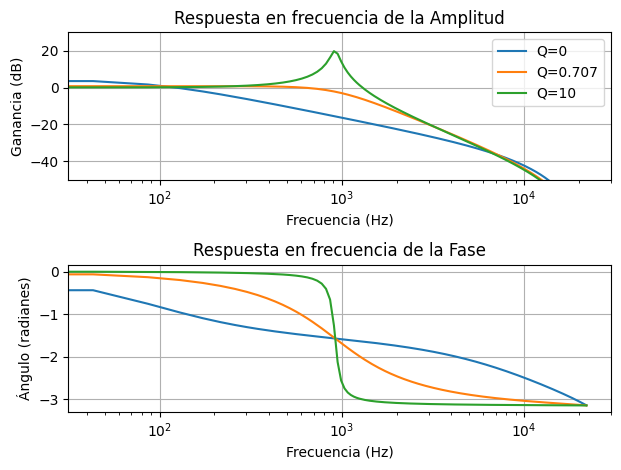

In [326]:
# Filtro biquad pasa bajos con frecuencia de corte $f_c$ y factor de calidad $Q$

def biquad_pasa_bajos(wc, Q):  
  alpha = np.sin(wc)/(2*Q)
  cos_wc = np.cos(wc)
  # coeficientes
  b = [(1-cos_wc)/2, 1-cos_wc, (1-cos_wc)/2]
  a = [1 + alpha, -2*cos_wc, 1 - alpha]
  # normalizar
  a = np.array(a)/a[0]
  b = np.array(b)/a[0]
  return b, a

fc = 1000
sr= 48000
wc = 2*np.pi*fc/sr

b, a = biquad_pasa_bajos(wc, 0.1)
axs = filterresponse(b, a)

b, a = biquad_pasa_bajos(wc, 0.707)
filterresponse(b, a, axs=axs);

b, a = biquad_pasa_bajos(wc, 10)
filterresponse(b, a, axs=axs);

axs[0].set_ylim(-50, 30);
axs[0].legend(["Q=0", "Q=0.707", "Q=10"]);

## Filtrar señales

Es posible filtrar audio o señales a partir de los coeficientes $a$ y $b$ con la función _lfilter_.

Filtremos ruido con el filtro:

$$
\begin{align}
b_0 &= 1\\
b_1 &= 1\\
a_0 &= 1+\alpha\\
a_1 &= 1-\alpha\\
\end{align}
$$

Con $\alpha = 2 SR / \omega_c$.


'Ruido blanco'

'Filtro orden 1'

'Filtro orden 2'

'Filtro orden 3'

'Filtro orden 4'

'Filtro orden 5'

'Filtro orden 6'

'Filtro orden 7'

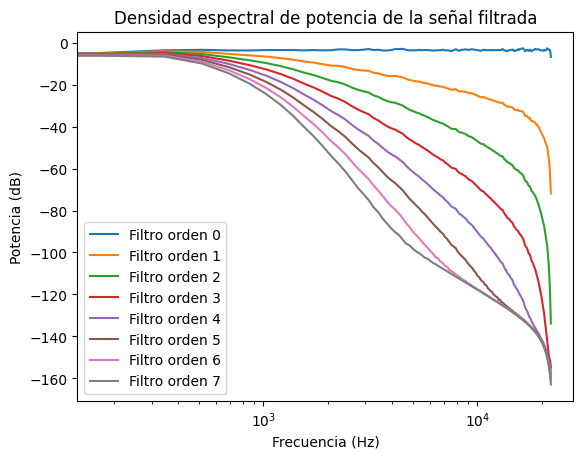

In [327]:
sr = 44100
dur = 0.8
N = int(dur*sr)
ys = []

# señal de entrada
x = np.random.randn(N)*100
display('Ruido blanco')
display(Audio(x,rate=sr))
ys.append(x)
wc = 2*np.pi*1000
alpha = 2*sr/wc
b = [1, 1]
a = [1+alpha, 1-alpha]

# señal filtrada
y = lfilter(b,a,x)
display('Filtro orden 1')
display(Audio(y,rate=sr))
ys.append(y)

# filtrar más veces
for i in range(6):
  y = lfilter(b,a,y)  
  ys.append(y)
  display('Filtro orden {}'.format(i+2))
  display(Audio(y,rate=sr))

## plot frecuency response of ys with scipy pwelch
from scipy.signal import welch
plt.figure()
for i,y in enumerate(ys):
  f, Pxx = welch(y, fs=sr, nperseg=256)
  Pdb = 10*np.log10(Pxx)
  plt.semilogx(f, Pdb,  label='Filtro orden {}'.format(i))
plt.legend();
plt.title("Densidad espectral de potencia de la señal filtrada")
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Potencia (dB)');

## Filtros con valores Complejos: Resonador

Los coeficientes de un filtro pueden tomar valores complejos, esto permite realizar ciertos filtrados con un orden de filtro menor, por ejemplo un resonador.

$$
\begin{align}
b_0 &= 1-R \\
b_1 &= 0 \\
a_0 &= 1\\
a_1 &= -c R\\
\end{align}
$$

Con:

$$
\begin{align}
R &= e^{-\frac{\pi B}{SR}}\\
c &= e^{j\frac{\omega_c}{SR}}
\end{align}
$$


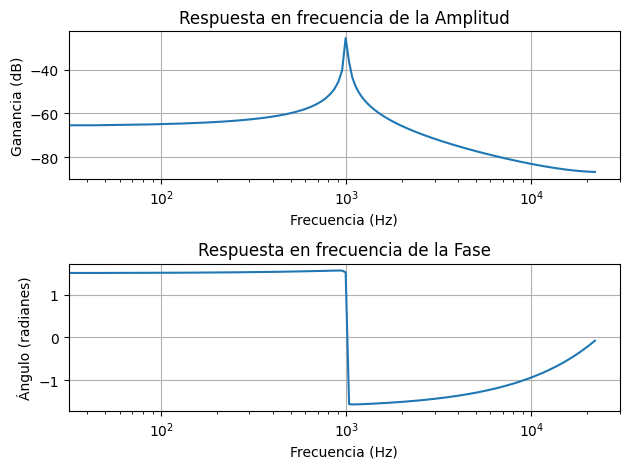

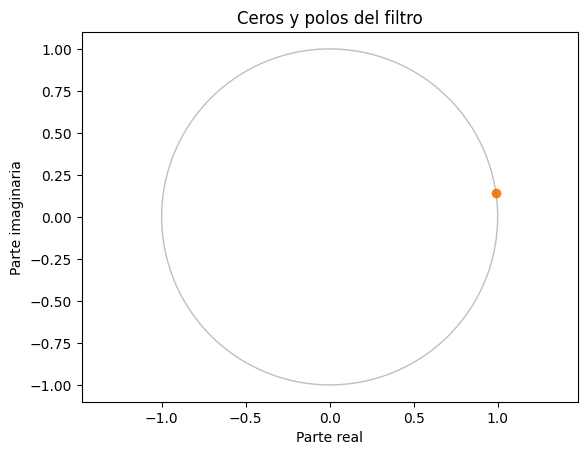

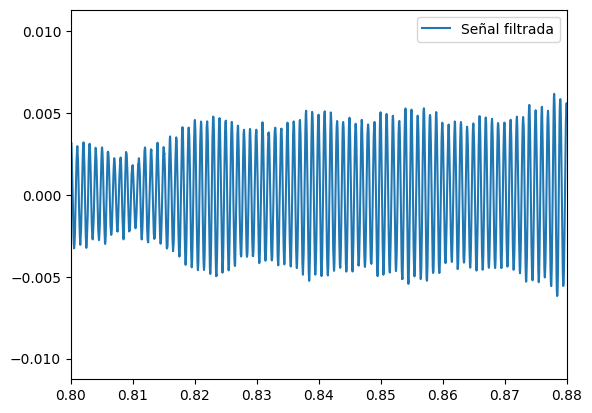

In [336]:
sr = 44100
fc = 1000
wc = 2*np.pi*fc
alpha = wc/sr

B = 1
R = np.exp(-np.pi*B/sr)
c = np.exp(1j*alpha)

b = [(1-R)]
a = [1,-c*R]
filterresponse(b,a);

# plot zeros and poles
zeros, polos, gain = tf2zpk(b, a)

plt.figure()
plt.scatter(np.real(zeros), np.imag(zeros), label='Ceros', marker='x')
plt.scatter(np.real(polos), np.imag(polos), label='Polos', marker='o')
# circulo unitario con matplotlib patches
circle = plt.Circle((0,0), 1, fill=False, color='gray', alpha=0.5)
plt.gca().add_patch(circle)
plt.title("Ceros y polos del filtro")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.xlim(-1.1,1.1)
plt.ylim(-1.1,1.1)
plt.axis('equal')

dur = 1.0
N = int(dur*sr)

# señal de entrada
x = np.random.randn(N)

# señal filtrada
y = lfilter(b,a,x).real
t = np.arange(N)/sr

plt.figure()
plt.plot(t,y , label='Señal filtrada')
plt.xlim(0.8,0.88)
plt.legend();

display(Audio(x,rate=sr))
display(Audio(y,rate=sr))

Podemos armar un sintetizador en base a filtros resonadores afinados

In [329]:
sr = 44100

def filtroresonador(fc, B = 10):
  wc = 2*np.pi*fc
  alpha = wc/sr  
  R = np.exp(-np.pi*B/sr)
  c = np.exp(1j*alpha)
  b = [(1-R)]
  a = [1,-c*R]
  return b,a 

dur = 2.0
N = int(dur*sr)

# señal de entrada
x = np.random.randn(N)
y = np.zeros(N)

# señal filtrada
for fc in [500,500*5/4,500*3/2]:
  b,a = filtroresonador(fc, 0.1)
  y += lfilter(b,a,x).real

display(Audio(x,rate=sr))
display(Audio(y,rate=sr))

## Diseño de filtro FIR con cuadrados mínimos

Se puede diseñar un filtro FIR de orden arbitrario para que su respuesta en frecuencia se aproxime a una deseada. Para esto se utiliza el método de cuadrados mínimos. La idea es minimizar la diferencia entre la respuesta en frecuencia del filtro y la deseada. El problema se puede plantear de forma matricial construyendo la matriz que calcula la DFT para señales reales y simétricas en base a cosenos.

$$
\underbrace{
\begin{bmatrix}
H(\omega_0) \\
H(\omega_1) \\
\vdots \\
H(\omega_{N-1})
\end{bmatrix}
}_{\mathbf{d}}
\approx
\underbrace{
\begin{bmatrix}
1 & 2\cos(\omega_0) & \cdots & 2\cos[\omega_0 (L/2)] \\
1 & 2\cos(\omega_1) & \cdots & 2\cos[\omega_1 (L/2)] \\
\vdots & \vdots & \ddots & \vdots \\
1 & 2\cos(\omega_{N-1}) & \cdots & 2\cos[\omega_{N-1} (L/2)]
\end{bmatrix}
}_{\mathbf{A}}
\underbrace{
\begin{bmatrix}
h_0 \\
h_1 \\
\vdots \\
h_{L/2}
\end{bmatrix}
}_{\mathbf{h}}
$$

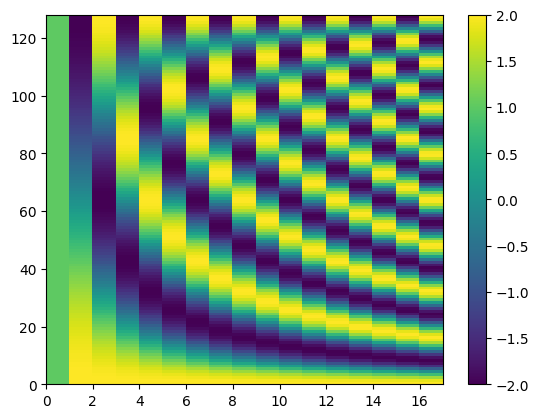

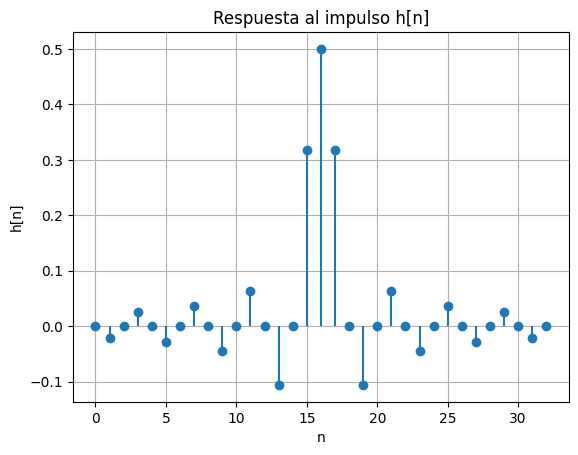

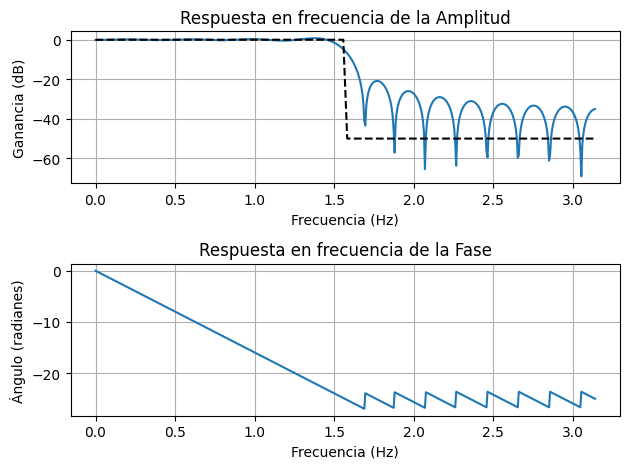

In [330]:
def matriz_cosenos(w, L):
    """
    Construye la matriz de cosenos para el diseño FIR.
    
    Parámetros:
    - w: array de frecuencias omega (en radianes)
    - L: longitud del filtro FIR (debe ser par)

    Retorna:
    - A: matriz de tamaño (len(w), L/2 + 1)
    """
    M = L // 2
    A = np.ones((len(w), M + 1))  # Primera columna de unos
    for k in range(1, M + 1):
        A[:, k] = 2 * np.cos(w * k)
    return A

# Ejemplo
L = 32                            # longitud del filtro (par)
N = 128                           # cantidad de frecuencias
w = np.linspace(0, np.pi, N)      # frecuencias de diseño
Hd = np.where(w < np.pi/2, 1, 0)  # respuesta deseada: paso bajo ideal

A = matriz_cosenos(w, L)

plt.figure()
plt.pcolor(A)
plt.colorbar()

h = np.linalg.lstsq(A, Hd, rcond=None)[0]

# espejar
h = np.r_[h[::-1], h[1:]]
# Visualización
plt.figure()
plt.stem(h, basefmt=" ")
plt.title("Respuesta al impulso h[n]")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.grid(True)
plt.show()

axs = filterresponse(h, [1], sr=2*np.pi, freq_scale='linear', phase_scale='linear');

# graficar la respuesta en frecuencia ideal
axs[0].plot(w, 10*np.log10(Hd+1e-5), 'k--', label='Respuesta en frecuencia ideal');

## Series temporales

Ajustemos coeficientes de un modelo AR a partir de datos sintéticos resolviendo las ecuaciones de Yule-Walker. 


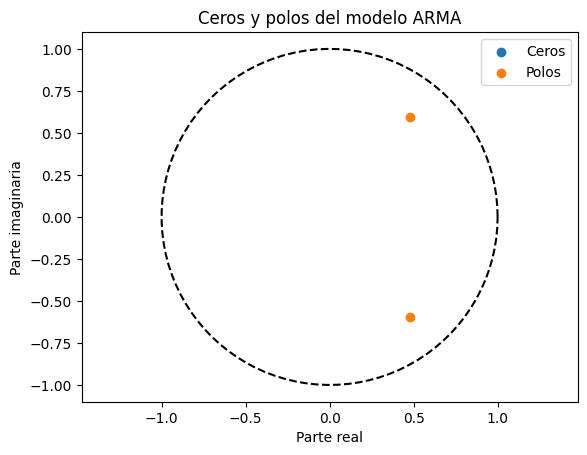

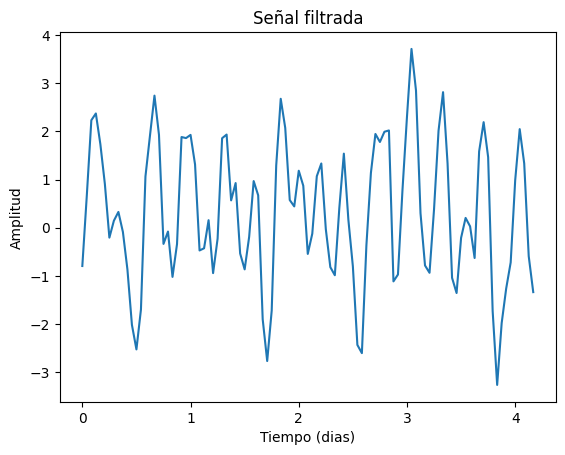

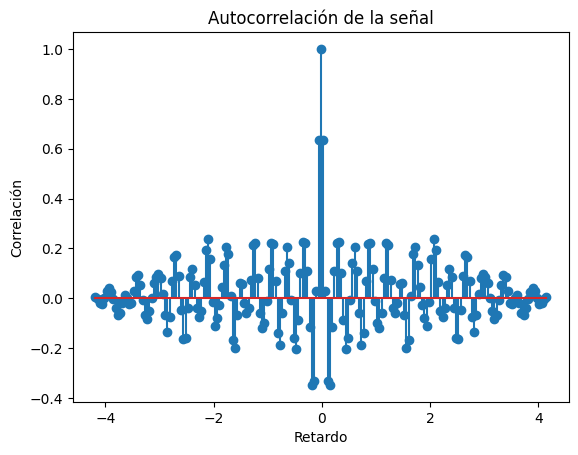

Coeficientes del modelo AR:
b = [1.]
a = [ 1.         -0.95304578  0.58141639]
Estimación de los coeficientes del modelo AR:
a_yw = [ 1.         -1.02661385  0.62041429]


In [331]:
# datos sintéticos
N = 101
sr = 24
t = np.arange(N)/sr
x = np.random.randn(N)

# modelo AR
q = 1

# coeficientes
b = [1]
a = np.r_[1, np.random.randn(q+1)]

# buscamos polos y ceros
zeros = np.roots(b)
polos = np.roots(a)

# si alguno polo esta fuera del circulo unitario, lo movemos al interior
if np.any(np.abs(polos) > 1):
  polos = polos/np.abs(polos)*np.random.rand()

# graficar
plt.figure()
plt.scatter(np.real(zeros), np.imag(zeros), label='Ceros')
plt.scatter(np.real(polos), np.imag(polos), label='Polos')
# circulo unitario
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), '--k')
plt.title("Ceros y polos del modelo ARMA")
plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.xlim(-1.1,1.1)
plt.ylim(-1.1,1.1)
plt.axis('equal')
plt.legend();

# de ceros y polos a coeficientes
b, a = zpk2tf(zeros, polos, 1)

# señal filtrada
y = lfilter(b,a,x)

# graficar
plt.figure()
plt.title("Señal filtrada")
plt.xlabel("Tiempo (dias)")
plt.ylabel("Amplitud")
plt.plot(t, y)


# calculamos autocorrelación de la señal
r = np.correlate(y, y, mode='full')
r = r/np.max(r)
tr = np.arange(len(r))/sr-len(r)/2/sr
# graficamos
plt.figure()
plt.stem(tr,r)
plt.title("Autocorrelación de la señal")
plt.xlabel("Retardo")
plt.ylabel("Correlación")
plt.show()

# Matriz de Yule-Walker
from scipy.linalg import toeplitz
r = np.fft.fftshift(r)[::-1]
q = 1
R = toeplitz(r[:q+1])
r_right = r[1:q+2]

# solución
a_yw = -np.linalg.solve(R, r_right)


print("Coeficientes del modelo AR:")
print("b =", b)
print("a =", a)

print("Estimación de los coeficientes del modelo AR:")
print("a_yw =", np.r_[1, a_yw])